In [12]:
import csv
import math
import os
from collections import defaultdict
from statistics import mean, stdev, median

def load_prices(day):
    """Load price data for a day, returns dict[product] -> list of (timestamp, mid, bid1, ask1, bid_vol1, ask_vol1)."""
    path = os.path.join(DATA_DIR, f'prices_round_3_day_{day}.csv')
    data = defaultdict(list)
    with open(path) as f:
        reader = csv.DictReader(f, delimiter=';')
        for row in reader:
            product = row['product']
            ts = int(row['timestamp'])
            mid = float(row['mid_price']) if row['mid_price'] else None
            bid1 = float(row['bid_price_1']) if row['bid_price_1'] else None
            ask1 = float(row['ask_price_1']) if row['ask_price_1'] else None
            bv1 = int(row['bid_volume_1']) if row['bid_volume_1'] else 0
            av1 = int(row['ask_volume_1']) if row['ask_volume_1'] else 0
            bid2 = float(row['bid_price_2']) if row['bid_price_2'] else None
            ask2 = float(row['ask_price_2']) if row['ask_price_2'] else None
            bv2 = int(row['bid_volume_2']) if row['bid_volume_2'] else 0
            av2 = int(row['ask_volume_2']) if row['ask_volume_2'] else 0
            if mid is not None:
                data[product].append((ts, mid, bid1, ask1, bv1, av1, bid2, ask2, bv2, av2))
    return data

def load_trades(day):
    """Load trade data for a day."""
    path = os.path.join(DATA_DIR, f'trades_round_3_day_{day}.csv')
    data = defaultdict(list)
    with open(path) as f:
        reader = csv.DictReader(f, delimiter=';')
        for row in reader:
            sym = row['symbol']
            ts = int(row['timestamp'])
            price = float(row['price'])
            qty = int(row['quantity'])
            data[sym].append((ts, price, qty))
    return data

all_prices = {}
all_trades = {}
DATA_DIR = "/home/mmaliar/prosperity4-tester-private/prosperity4bt/resources/round3"
STRIKES = [4000, 4500, 5000, 5100, 5200, 5300, 5400, 5500, 6000, 6500]
VEV_PRODUCTS = [f'VEV_{k}' for k in STRIKES]
DAYS = [0, 1, 2]
# TTE: day0=8d, day1=7d, day2=6d (from problem statement)
TTE_MAP = {0: 8/365, 1: 7/365, 2: 6/365}
R = 0.0  # risk-free rate (Prosperity convention)
for d in DAYS:
    all_prices[d] = load_prices(d)
    all_trades[d] = load_trades(d)

In [13]:
all_prices[0]

defaultdict(list,
            {'VEV_5400': [(0, 23.0, 22.0, 24.0, 25, 25, None, None, 0, 0),
              (100, 23.5, 23.0, 24.0, 17, 17, None, None, 0, 0),
              (200, 23.5, 23.0, 24.0, 10, 24, 22.0, None, 14, 0),
              (300, 23.5, 23.0, 24.0, 9, 20, 22.0, None, 11, 0),
              (400, 23.5, 23.0, 24.0, 6, 19, 22.0, None, 13, 0),
              (500, 23.0, 22.0, 24.0, 22, 22, None, None, 0, 0),
              (600, 23.0, 22.0, 24.0, 22, 22, None, None, 0, 0),
              (700, 23.0, 22.0, 24.0, 21, 21, None, None, 0, 0),
              (800, 22.5, 22.0, 23.0, 15, 15, None, None, 0, 0),
              (900, 22.5, 22.0, 23.0, 29, 29, None, None, 0, 0),
              (1000, 22.5, 22.0, 23.0, 23, 23, None, None, 0, 0),
              (1100, 23.0, 22.0, 24.0, 23, 23, None, None, 0, 0),
              (1200, 23.0, 22.0, 24.0, 18, 18, None, None, 0, 0),
              (1300, 22.5, 22.0, 23.0, 24, 24, None, None, 0, 0),
              (1400, 22.5, 22.0, 23.0, 22, 22, None, None

In [14]:
import matplotlib.pyplot as plt

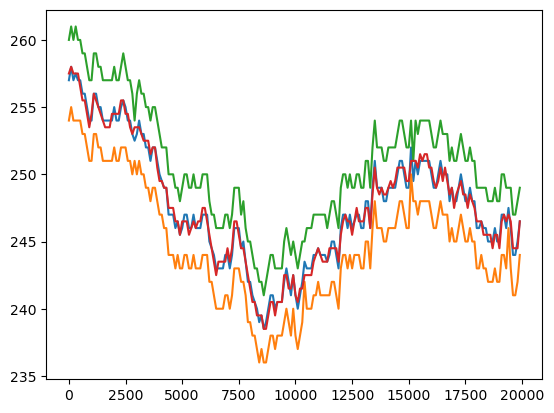

In [34]:
start = 0
end = 200
product = 'VEV_5000'
ts = [x[0] for x in all_prices[0][product]][start:end]
plt.plot(ts, [x[1] for x in all_prices[0][product]][start:end])
plt.plot(ts, [x[2] for x in all_prices[0][product]][start:end])
plt.plot(ts, [x[3] for x in all_prices[0][product]][start:end])

walls = []
spreads = []
for i in range(start, end):
    _, mid, bid1, ask1, bv1, av1, bid2, ask2, bv2, av2 = all_prices[0][product][i]
    if bv1 > bv2:
        bid = bid1
    else:
        bid = bid2
    if av1 > av2:
        ask = ask1
    else:
        ask = ask2
    walls.append((bid+ask)*0.5)
    spreads.append(ask-bid)
    
plt.plot(ts, walls)

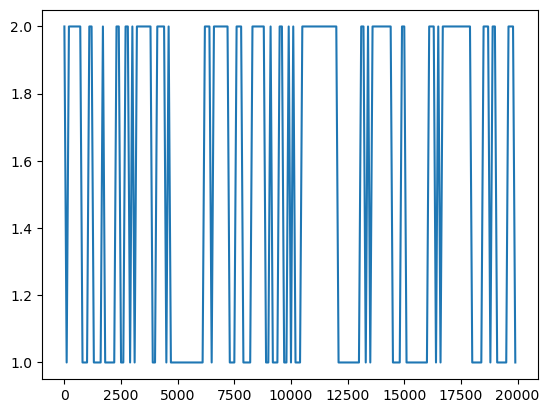

In [25]:
plt.plot(ts, spreads)

In [29]:
bid

20.0

In [30]:
ask

21.0